In [1]:
from distgen import Generator

from pmd_beamphysics import ParticleGroup
from pmd_beamphysics.interfaces.impact import parse_impact_particles, impact_particles_to_particle_data

import os

# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

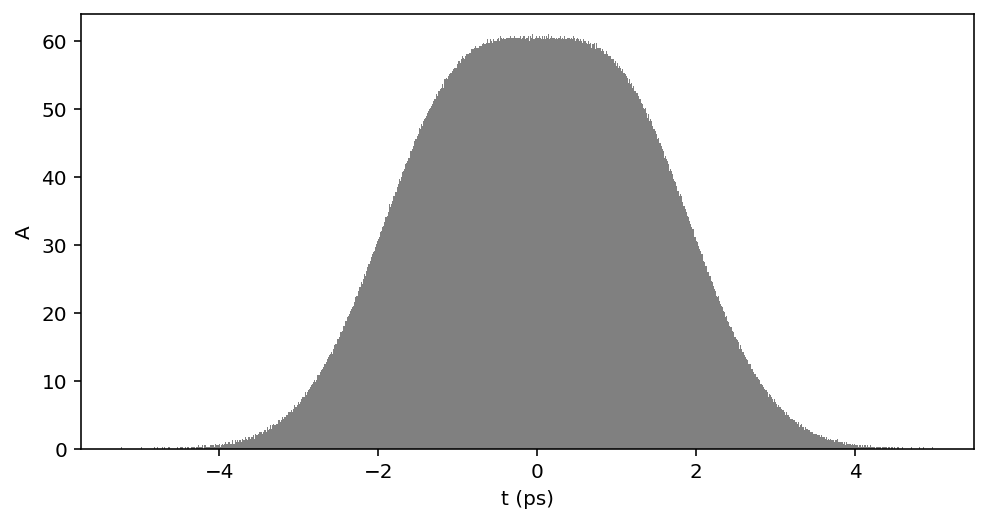

In [2]:
YAML="""
n_particle: 100000
random_type: hammersley

start:
  type: cathode
  MTE:
    value: 414
    units: meV    

total_charge:
  value: 250
  units: pC
    
r_dist:
  n_sigma_cutoff: 1.5
  sigma_xy:
    value: 0.4
    units: mm
  type: radial_gaussian

t_dist:
  type: superposition
  dists: 
    d1: 
      type: gaussian
      avg_t:
        units: ps
        value: -1
      sigma_t:
        units: ps
        value: 1
    d2: 
      type: gaussian
      avg_t:
        units: ps
        value: 1
      sigma_t:
        units: ps
        value: 1
"""

G = Generator(YAML)
G.run()
P1 = G.particles
P1.plot('t')


In [3]:
pfile = os.path.join(os.environ['LCLS_LATTICE'], 'impact/models/cu_inj/partcl.data')
assert os.path.exists(pfile)

tout = parse_impact_particles(pfile, skiprows=1)
data = impact_particles_to_particle_data(tout, mc2=0.511e6, species='electron', macrocharge=0, cathode_kinetic_energy_ref=1.0, verbose=True )
P2 = ParticleGroup(data=data)

# Center
P2.t -= P2['mean_t']

Converting z to t according to cathode_kinetic_energy_ref = 1.0 eV


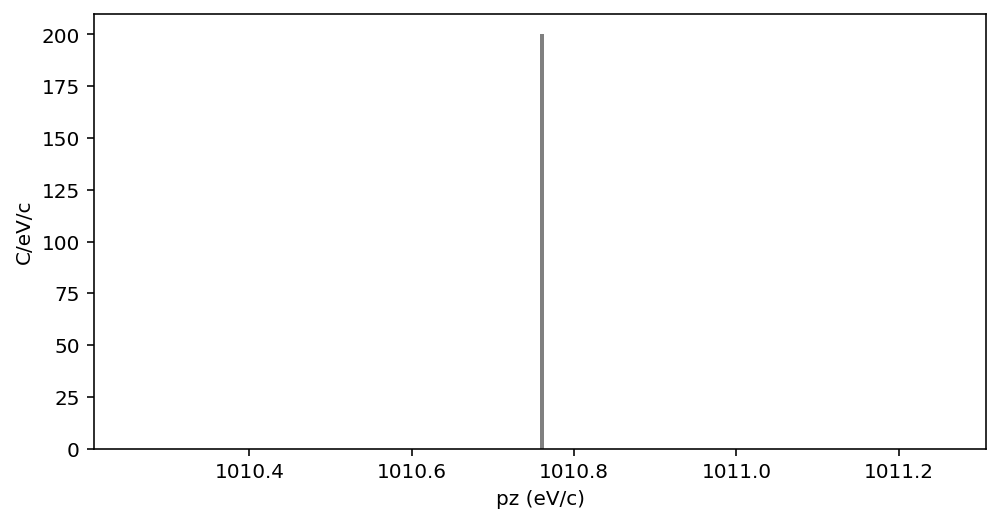

In [4]:
P2.plot('pz', bins=200)

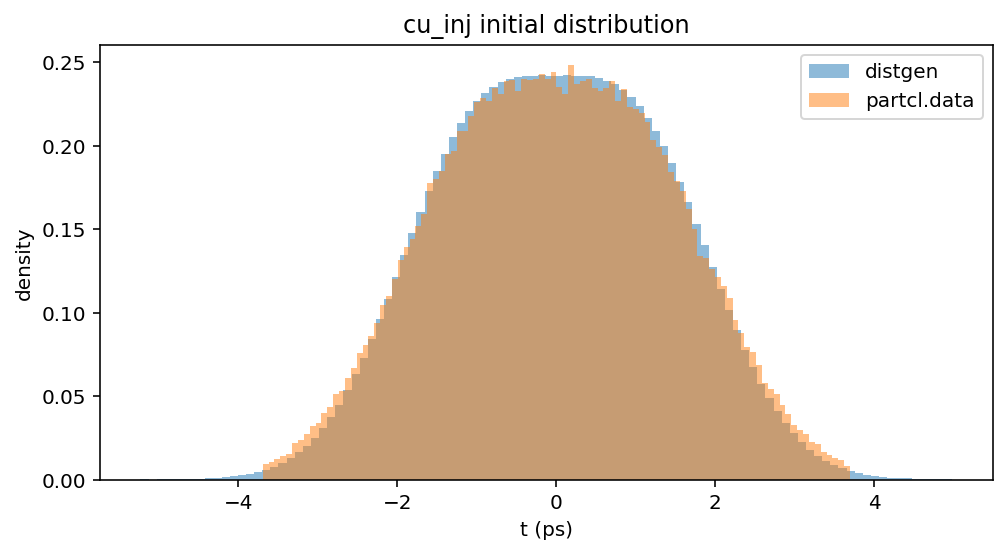

In [5]:
k = 't'
plt.hist(P1[k]*1e12, label='distgen', alpha = 0.5, density=True, bins=100)
plt.hist(P2[k]*1e12, label='partcl.data', alpha=0.5, density=True, bins=100)

plt.title('cu_inj initial distribution')
plt.xlabel('t (ps)')
plt.ylabel('density')
plt.legend()
#plt.savefig('test.png')

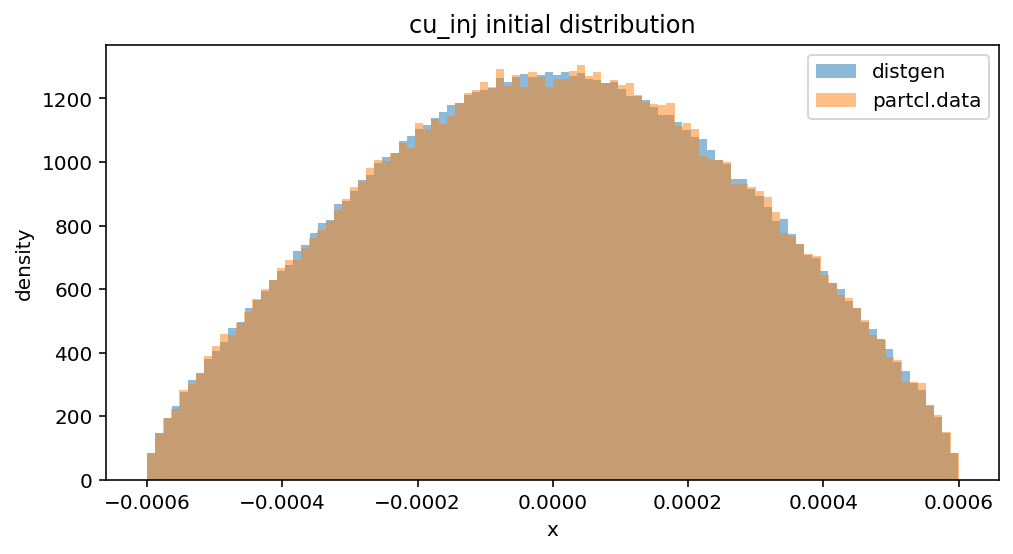

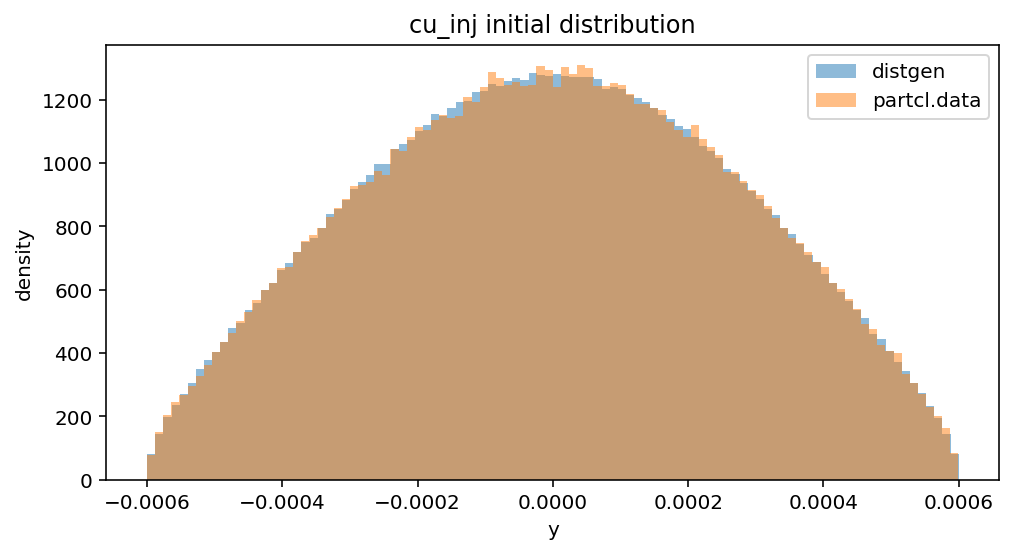

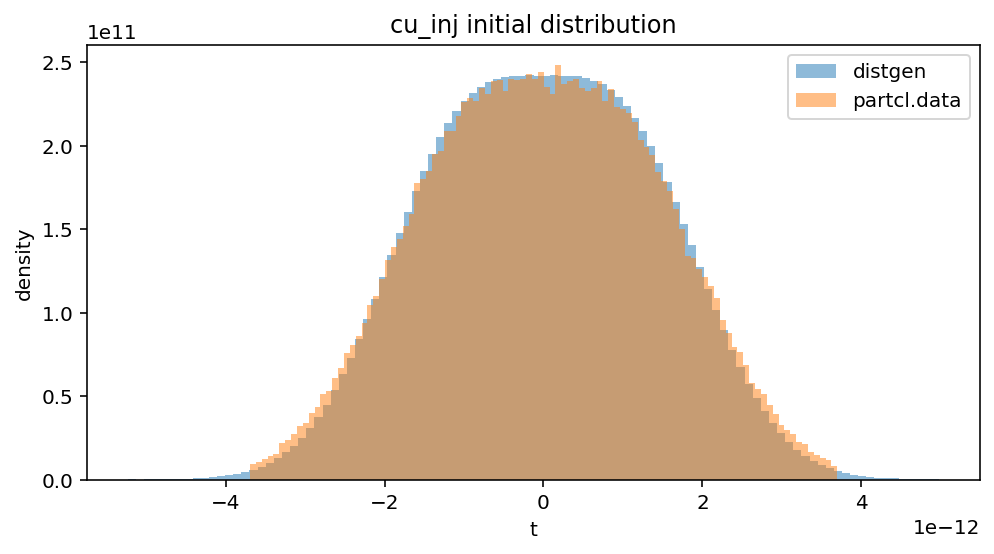

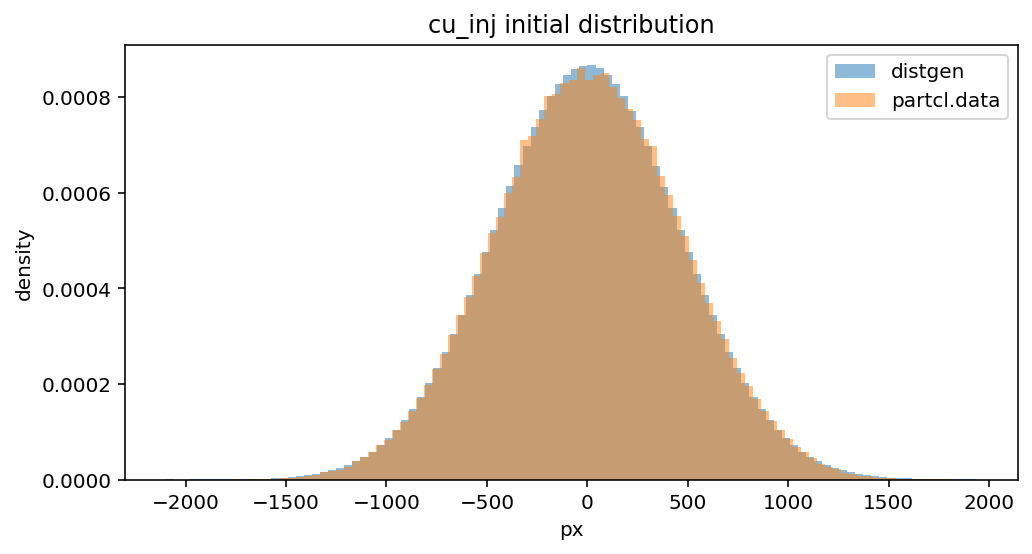

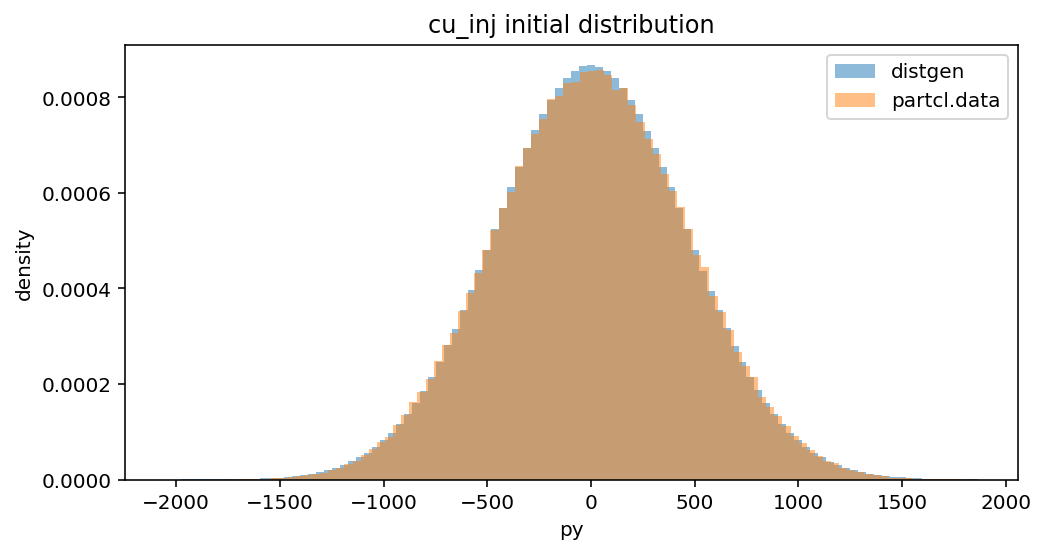

In [6]:
for k in ['x', 'y', 't', 'px', 'py']:
    plt.hist(P1[k], label='distgen', alpha = 0.5, density=True, bins=100)
    plt.hist(P2[k], label='partcl.data', alpha=0.5, density=True, bins=100)
    
    plt.title('cu_inj initial distribution')
    plt.xlabel(k)
    plt.ylabel('density')
    plt.legend()
    plt.show()